In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

In [3]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

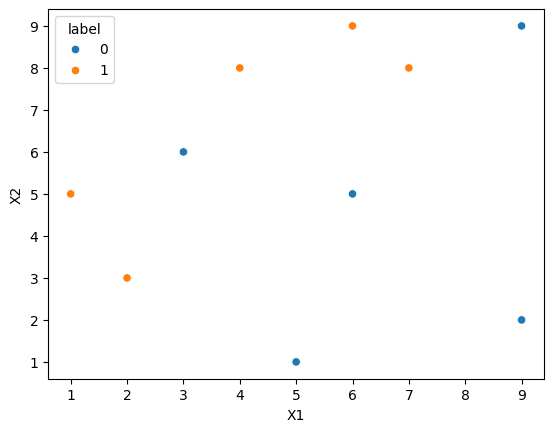

In [5]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [6]:
df['weights'] = 1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [10]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [11]:
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [12]:
from sklearn.tree import plot_tree

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

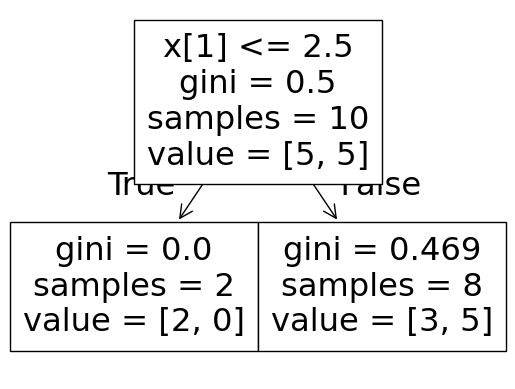

In [13]:
plot_tree(dt1)

<Axes: >

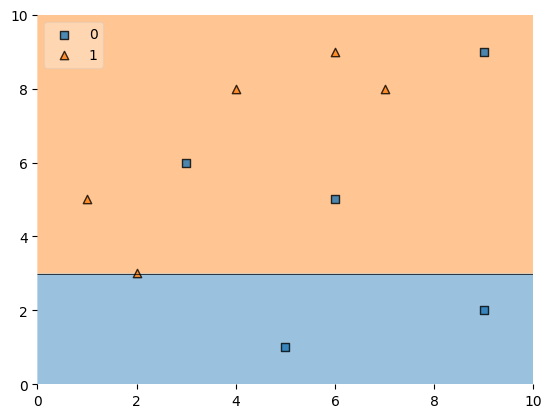

In [14]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [15]:
df['y_pred'] = dt1.predict(X)

In [16]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [17]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))

In [18]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [19]:
def update_row_weight(row,alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [20]:
df['update_row_weight'] = df.apply(update_row_weight,axis=1)

In [21]:
df

,X1,X2,label,weights,y_pred,update_row_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [22]:
# calculate sum of the update row weight and not 1 and use normalization
df['normalized_weight'] = df['update_row_weight']/df['update_row_weight'].sum()

In [23]:
df

,X1,X2,label,weights,y_pred,update_row_weight,normalized_weight
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [24]:
df['normalized_weight'].sum() # it is 1 is total normalized weight

np.float64(1.0)

In [25]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])

In [26]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weight']

In [27]:
df[['X1','X2','label','weights','y_pred','normalized_weight','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weight,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.071475,0.000000,0.071475
1,2,3,1,0.1,1,0.071475,0.071475,0.142950
2,3,6,0,0.1,1,0.166559,0.142950,0.309508
3,4,8,1,0.1,1,0.071475,0.309508,0.380983
4,5,1,0,0.1,0,0.071475,0.380983,0.452458
5,6,9,1,0.1,1,0.071475,0.452458,0.523933
6,6,5,0,0.1,1,0.166559,0.523933,0.690492
7,7,8,1,0.1,1,0.071475,0.690492,0.761967
8,9,9,0,0.1,1,0.166559,0.761967,0.928525
9,9,2,0,0.1,0,0.071475,0.928525,1.000000


In [28]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [29]:
index_values = create_new_dataset(df)

In [30]:
index_values

[6, 2, 6, 8, 8, 5, 5, 6, 8, 0]

In [31]:
df = df.iloc[index_values,[0,1,2,3]]

In [32]:
df

,X1,X2,label,weights
6,6,5,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1
0,1,5,1,0.1


In [33]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [34]:
dt2.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

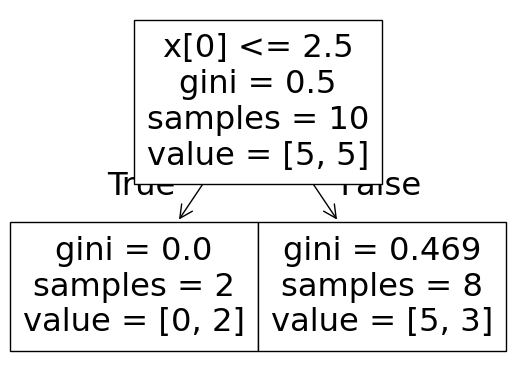

In [35]:
plot_tree(dt2)

<Axes: >

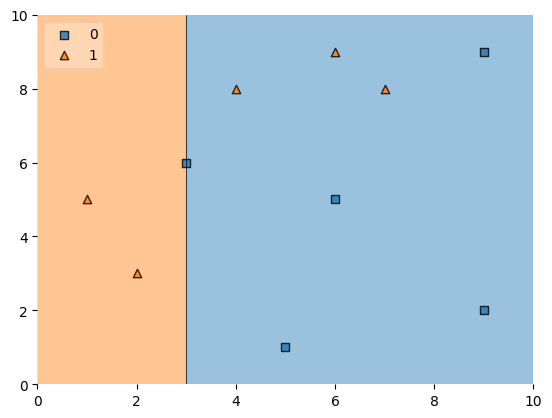

In [36]:
plot_decision_regions(X,y,clf=dt2,legend=2)

In [37]:
df['y_pred'] = dt2.predict(X)

In [38]:
df

,X1,X2,label,weights,y_pred
6,6,5,0,0.1,1
2,3,6,0,0.1,1
6,6,5,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,0
5,6,9,1,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,0
0,1,5,1,0.1,0


In [40]:
alpha2 = calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [42]:
def update_row_weight(row,alpha=1.09):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [43]:
df['updated_weights'] = df.apply(update_row_weight,axis=1)

In [44]:
df

,X1,X2,label,weights,y_pred,updated_weights
6,6,5,0,0.1,1,0.297427
2,3,6,0,0.1,1,0.297427
6,6,5,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
5,6,9,1,0.1,0,0.297427
5,6,9,1,0.1,0,0.297427
6,6,5,0,0.1,0,0.033622
8,9,9,0,0.1,0,0.033622
0,1,5,1,0.1,0,0.297427


In [46]:
# calculate sum of the update row weight and not 1 and use normalization
df['normalized_weight'] = df['updated_weights']/df['updated_weights'].sum()

In [48]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weight
6,6,5,0,0.1,1,0.297427,0.179688
2,3,6,0,0.1,1,0.297427,0.179688
6,6,5,0,0.1,0,0.033622,0.020312
8,9,9,0,0.1,0,0.033622,0.020312
8,9,9,0,0.1,0,0.033622,0.020312
5,6,9,1,0.1,0,0.297427,0.179688
5,6,9,1,0.1,0,0.297427,0.179688
6,6,5,0,0.1,0,0.033622,0.020312
8,9,9,0,0.1,0,0.033622,0.020312
0,1,5,1,0.1,0,0.297427,0.179688


In [49]:
df['normalized_weight'].sum()

np.float64(0.9999999999999999)

In [50]:
df['cumsum_upper'] = np.cumsum(df['normalized_weight'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weight']
df[['X1','X2','label','weights','y_pred','normalized_weight','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weight,cumsum_lower,cumsum_upper
6,6,5,0,0.1,1,0.179688,0.000000,0.179688
2,3,6,0,0.1,1,0.179688,0.179688,0.359376
6,6,5,0,0.1,0,0.020312,0.359376,0.379688
8,9,9,0,0.1,0,0.020312,0.379688,0.400000
8,9,9,0,0.1,0,0.020312,0.400000,0.420312
5,6,9,1,0.1,0,0.179688,0.420312,0.600000
5,6,9,1,0.1,0,0.179688,0.600000,0.779688
6,6,5,0,0.1,0,0.020312,0.779688,0.800000
8,9,9,0,0.1,0,0.020312,0.800000,0.820312
0,1,5,1,0.1,0,0.179688,0.820312,1.000000


In [51]:
index_values = create_new_dataset(df)

In [52]:
tdf = df.iloc[index_values,[0,1,2,3]]

In [53]:
tdf

,X1,X2,label,weights
5,6,9,1,0.1
6,6,5,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1
6,6,5,0,0.1
6,6,5,0,0.1


In [55]:
dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

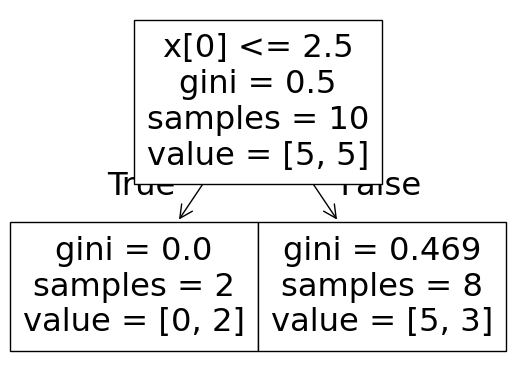

In [56]:
plot_tree(dt3)

<Axes: >

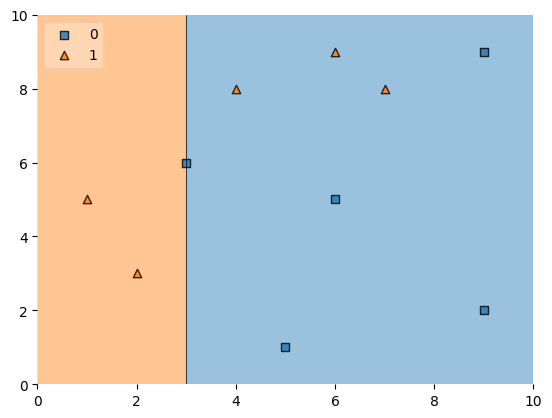

In [57]:
plot_decision_regions(X,y,clf=dt3,legend=2)

In [58]:
tdf['y_pred'] = dt3.predict(X)

In [59]:
tdf

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,1
6,6,5,0,0.1,1
6,6,5,0,0.1,0
6,6,5,0,0.1,0
5,6,9,1,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,0
6,6,5,0,0.1,0
6,6,5,0,0.1,0


In [60]:
alpaa3 = calculate_model_weight(0.3)

In [61]:
alpaa3

np.float64(0.42364893019360184)

In [62]:
print(alpha1,alpha2,alpaa3)

0.42364893019360184 1.0986122886681098 0.42364893019360184


In [64]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [65]:
dt2.predict(query)

array([1])

In [66]:
dt3.predict(query)

array([1])

In [68]:
alpha1*1 + alpha2*(1) + alpaa3*(1)

np.float64(1.9459101490553135)

In [69]:
np.sign(1.94)

np.float64(1.0)

In [70]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1])

In [71]:
dt2.predict(query)

array([0])

In [72]:
dt3.predict(query)

array([0])

In [75]:
alpha1*(1) + alpha2*(-1) + alpaa3*(-1)

np.float64(-1.0986122886681098)

In [76]:
np.sign(-1.09)

np.float64(-1.0)